In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import kagglehub

tf.random.set_seed(42)
np.random.seed(42)


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [ ]:
path = kagglehub.dataset_download("arjuntejaswi/plant-village")
print("✅ Dataset downloaded to:", path)


print("\n🔍 Exploring downloaded directory structure:")
def explore_structure(start_path, max_depth=4, current_depth=0):
    if current_depth > max_depth:
        return

    indent = "  " * current_depth
    try:
        items = os.listdir(start_path)
        for item in items:
            item_path = os.path.join(start_path, item)
            if os.path.isdir(item_path):
                print(f"{indent}📁 {item}/")
                explore_structure(item_path, max_depth, current_depth + 1)
            else:

                if item.lower().endswith(('.png', '.jpg', '.jpeg', '.zip', '.tar', '.gz')):
                    print(f"{indent}📄 {item}")
    except PermissionError:
        print(f"{indent}🚫 Permission denied: {item_path}")

explore_structure(path)


possible_paths = [
    os.path.join(path, "PlantVillage"),
    os.path.join(path, "plant_village"),
    os.path.join(path, "Plant_Village"),
    os.path.join(path, "PlantVillage-Dataset", "raw", "color"),
    os.path.join(path, "PlantVillage-Dataset", "color"),
    os.path.join(path, "PlantVillage-Dataset"),
    os.path.join(path, "dataset"),
    os.path.join(path, "data"),
    path
]

DATASET_DIR = None
for p in possible_paths:
    if os.path.exists(p) and os.path.isdir(p):

        subdirs = [d for d in os.listdir(p) if os.path.isdir(os.path.join(p, d))]
        if subdirs:
            DATASET_DIR = p
            print(f"✅ Found potential dataset directory: {p}")
            print(f"   Contains {len(subdirs)} subdirectories")
            break

if DATASET_DIR is None:

    compressed_files = [f for f in os.listdir(path) if f.lower().endswith(('.zip', '.tar', '.gz'))]
    if compressed_files:
        print(f"📦 Found compressed files: {compressed_files}")
        print("⚠️  You need to extract the dataset first!")

        raise FileNotFoundError("❌ Dataset is compressed. Please extract it first.")
    else:
        raise FileNotFoundError("❌ Could not find PlantVillage dataset. Check the structure above.")

print("✅ Using dataset directory:", DATASET_DIR)


print(f"\n📊 Contents of {DATASET_DIR}:")
items = os.listdir(DATASET_DIR)
for item in items:
    item_path = os.path.join(DATASET_DIR, item)
    if os.path.isdir(item_path):

        image_files = [f for f in os.listdir(item_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        print(f"📁 {item}/ ({len(image_files)} images)")
    else:
        print(f"📄 {item}")

class_names = []
for d in os.listdir(DATASET_DIR):
    dir_path = os.path.join(DATASET_DIR, d)
    if os.path.isdir(dir_path):
        image_files = [f for f in os.listdir(dir_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if image_files:
            class_names.append(d)

class_names = sorted(class_names)

if not class_names:
    print("❌ No class directories found with images!")
    print("The directory structure might be:")
    print("1. All images in one folder (need to reorganize)")
    print("2. Nested differently than expected")
    print("3. Compressed files need extraction")
else:
    print(f"\n📋 Found {len(class_names)} classes with images:")
    for i, c in enumerate(class_names):
        class_path = os.path.join(DATASET_DIR, c)
        num_images = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        print(f" {i+1:2d}. {c}: {num_images} images")

Streaming output truncated to the last 5000 lines.
    📄 2d71f791-64fd-4f1a-97f6-812780014edd___JR_HL 7653.JPG
    📄 5bb2ecb4-acf6-464c-a62e-c76a110fe22c___JR_HL 8890.JPG
    📄 46ee2cd9-3312-43de-928e-6b9de2f01e82___JR_HL 7658.JPG
    📄 b39dd01c-b297-4d3f-ad79-c06a488a99cd___JR_HL 8268.JPG
    📄 7a4be7ca-f56e-483e-b4e3-cf5ed0759a42___JR_HL 8078.JPG
    📄 bde06fef-b8e8-445f-a180-376219cee0bb___JR_HL 5858.JPG
    📄 fef2be54-15b6-43ad-9d5e-7c30aebc0805___JR_HL 8892.JPG
    📄 03c966a7-ac9e-4c8e-965a-6c0e7289a0e8___JR_HL 8509.JPG
    📄 6189bc8c-6309-4692-8fa2-efe95f3c27d1___JR_HL 7802.JPG
    📄 de8f27ad-c53f-4481-affe-174d3690d559___JR_HL 8562.JPG
    📄 36a22116-062b-462c-9fed-37e5d2e4bc8b___JR_HL 8338.JPG
    📄 598dad0c-6cea-40e6-9b83-2e0473cebe9b___JR_HL 8051.JPG
    📄 f06eae04-68c4-482c-b78c-7213afe6e759___JR_HL 8011.JPG
    📄 7dfaee93-0cc9-4173-9622-cc3e877474c6___JR_HL 8447.JPG
    📄 cc799066-155d-4d7d-9229-93db4e6be216___JR_HL 8421.JPG
    📄 aa47c0e2-f03e-4d8b-b665-2c625fadc100___JR_H

In [ ]:

IMG_SIZE = (128, 128)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)


train_ds = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset="training",
    class_mode="categorical",
    shuffle=True,
    seed=123
)

val_ds = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset="validation",
    class_mode="categorical",
    shuffle=False,
    seed=123
)


steps_per_epoch = train_ds.samples // train_ds.batch_size
validation_steps = val_ds.samples // val_ds.batch_size

print(f"📊 Training samples: {train_ds.samples}")
print(f"📊 Validation samples: {val_ds.samples}")
print(f"📊 Steps per epoch: {steps_per_epoch}")
print(f"📊 Validation steps: {validation_steps}")


train_dataset = tf.data.Dataset.from_generator(
    lambda: train_ds,
    output_signature=(
        tf.TensorSpec(shape=(None, IMG_SIZE[0], IMG_SIZE[1], 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, num_classes), dtype=tf.float32)
    )
).repeat()

val_dataset = tf.data.Dataset.from_generator(
    lambda: val_ds,
    output_signature=(
        tf.TensorSpec(shape=(None, IMG_SIZE[0], IMG_SIZE[1], 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, num_classes), dtype=tf.float32)
    )
).repeat()

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.
📊 Training samples: 16516
📊 Validation samples: 4122
📊 Steps per epoch: 1032
📊 Validation steps: 257


In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=IMG_SIZE + (3,)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation='softmax')
])


optimizer = Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy", "precision", "recall"]
)


model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,553,295 (25.00 MB)

 Trainable params: 6,552,079 (24.99 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [ ]:
EPOCHS = 8

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7),
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max'
    )
]


history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/8
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 125s 108ms/step - accuracy: 0.3799 - loss: 2.0885 - precision: 0.5423 - recall: 0.2349 - val_accuracy: 0.5000 - val_loss: 1.7617 - val_precision: 0.5973 - val_recall: 0.4275 - learning_rate: 0.0010
Epoch 2/8
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 115s 105ms/step - accuracy: 0.5987 - loss: 1.2214 - precision: 0.7380 - recall: 0.4562 - val_accuracy: 0.3848 - val_loss: 2.2693 - val_precision: 0.4321 - val_recall: 0.3288 - learning_rate: 0.0010
Epoch 3/8
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 142s 137ms/step - accuracy: 0.6671 - loss: 1.0152 - precision: 0.7805 - recall: 0.5557 - val_accuracy: 0.5852 - val_loss: 1.2860 - val_precision: 0.6519 - val_recall: 0.5314 - learning_rate: 0.0010
Epoch 4/8
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 142s 138ms/step - accuracy: 0.7005 - loss: 0.9041 - precision: 0.7975 - recall: 0.6112 - val_accuracy: 0.7292 - val_loss: 0.8224 - val_precision: 0.7834 - val_recall: 0.6819 - learning_rate: 0.0010
Epoch 5/8
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 141

258/258 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step
📊 True labels shape: (4122,)
📊 Predictions shape: (4122,)
✅ Accuracy: 0.7892 (78.92%)
✅ Precision: 0.8244
✅ Recall: 0.7892
✅ F1-Score: 0.7796

📋 Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.95      0.64      0.77       199
                     Pepper__bell___healthy       0.77      0.98      0.86       295
                      Potato___Early_blight       0.57      0.99      0.73       200
                       Potato___Late_blight       0.68      0.81      0.74       200
                           Potato___healthy       0.62      0.80      0.70        30
                      Tomato_Bacterial_spot       0.89      0.96      0.93       425
                        Tomato_Early_blight       0.90      0.39      0.54       200
                         Tomato_Late_blight       0.94      0.62      0.74       381
                        

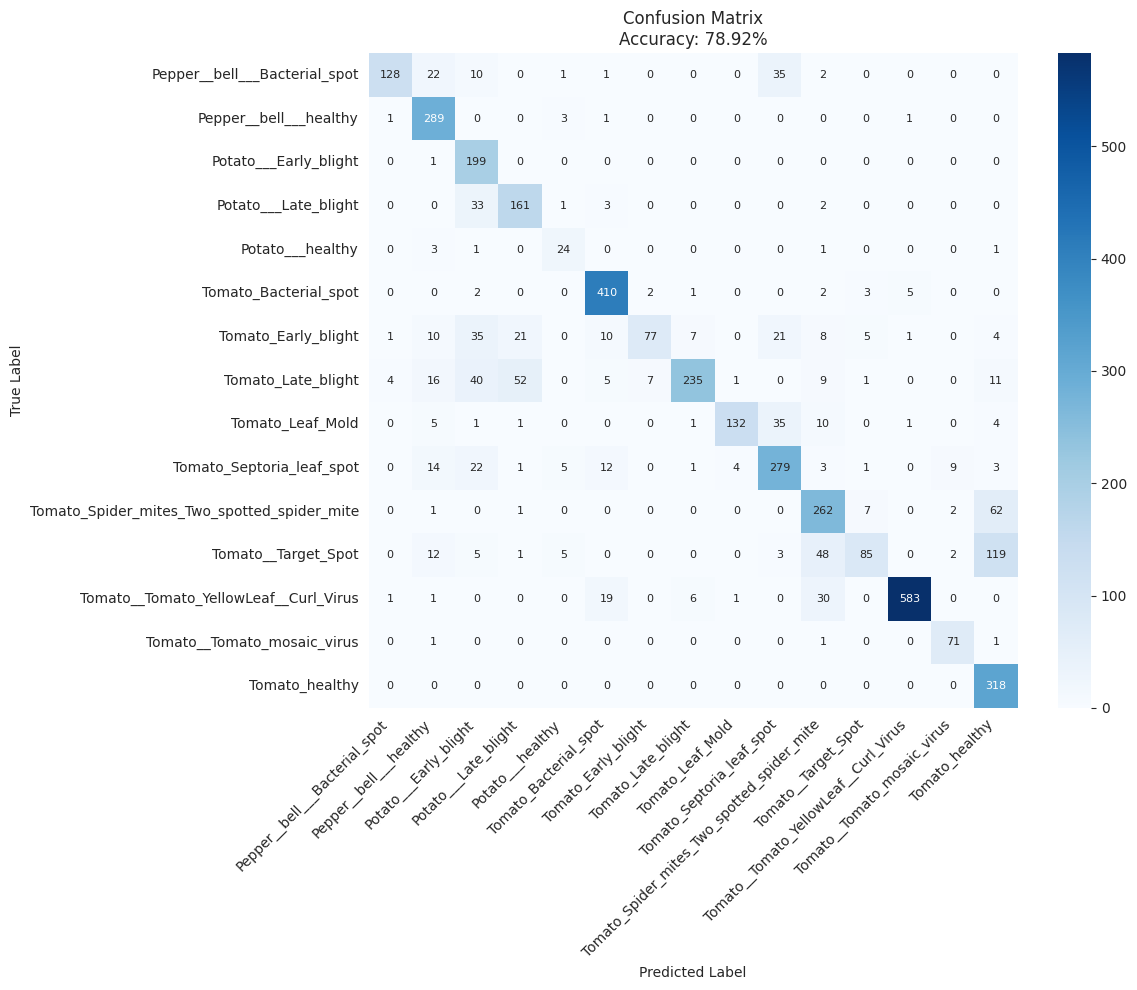

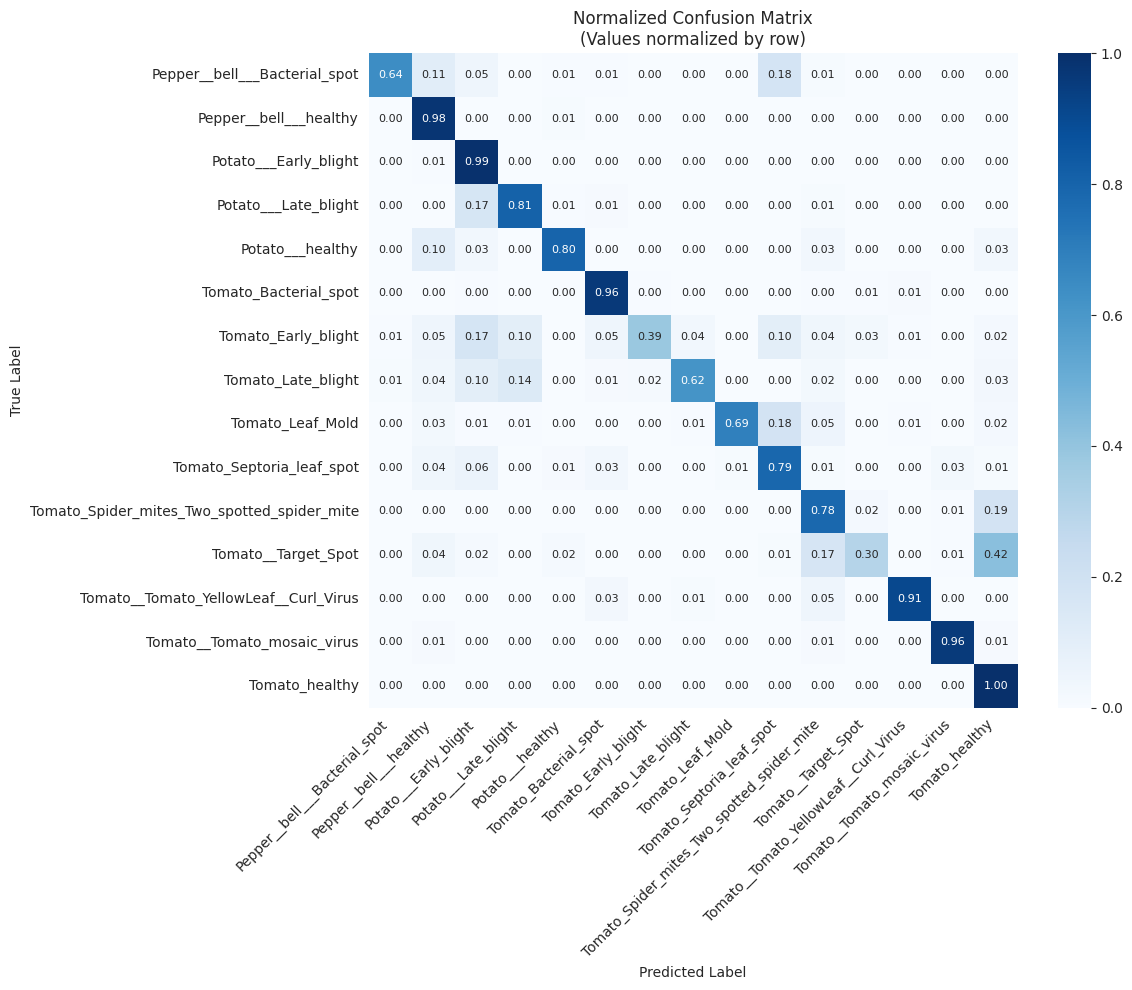

In [ ]:

val_ds.reset()


y_pred_probs = model.predict(val_ds, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)


y_true = val_ds.classes



num_samples = len(y_true)
y_pred = y_pred[:num_samples]

print(f"📊 True labels shape: {y_true.shape}")
print(f"📊 Predictions shape: {y_pred.shape}")


cm = confusion_matrix(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)


print("✅ Accuracy: {:.4f} ({:.2f}%)".format(acc, acc * 100))
print("✅ Precision: {:.4f}".format(precision_score(y_true, y_pred, average='weighted')))
print("✅ Recall: {:.4f}".format(recall_score(y_true, y_pred, average='weighted')))
print("✅ F1-Score: {:.4f}".format(f1_score(y_true, y_pred, average='weighted')))


print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names_ordered))


plt.figure(figsize=(12, 10))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap="Blues",
            xticklabels=class_names_ordered,
            yticklabels=class_names_ordered,
            annot_kws={'size': 8})
plt.title("Confusion Matrix\nAccuracy: {:.2f}%".format(acc * 100))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 10))
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized,
            annot=True,
            fmt='.2f',
            cmap="Blues",
            xticklabels=class_names_ordered,
            yticklabels=class_names_ordered,
            annot_kws={'size': 8})
plt.title("Normalized Confusion Matrix\n(Values normalized by row)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
model.save("/content/drive/MyDrive/plant_disease_model.keras")
print("✅ Model saved at /content/drive/MyDrive/plant_disease_model.keras")

✅ Model saved at /content/drive/MyDrive/plant_disease_model.keras
